# Lab: Comparing Classification Decision Boundaries

This lab reproduces the main idea to compare how different classifiers partition a two-dimensional feature space.

We will study four classifiers:

1. **k-Nearest Neighbors (k-NN)**
2. **Linear Support Vector Machine (Linear SVM)**
3. **Decision Tree**
4. **Gaussian Naive Bayes**

We will apply them to three synthetic datasets:

- Two interleaving moons
- Concentric circles
- A roughly linearly separable dataset

The background color shows each model's predicted class and confidence. The points show the actual samples.

## Learning objectives

By the end of this lab, you should be able to:

- Explain what a **decision boundary** is.
- Compare linear and nonlinear classifiers.
- Identify underfitting and overfitting from a visualization.
- Relate a model's assumptions to the shape of its decision regions.
- Evaluate models using a held-out test set.

In [1]:
# Run this cell first.
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Create the datasets

Each dataset has two features so that we can draw the decision boundary directly.

In [2]:
# Dataset 1: nonlinear, moon-shaped classes
X_moons, y_moons = make_moons(
    n_samples=200, noise=0.25, random_state=RANDOM_STATE
)

# Dataset 2: nonlinear, concentric circles
X_circles, y_circles = make_circles(
    n_samples=200, noise=0.15, factor=0.45, random_state=RANDOM_STATE
)

# Dataset 3: approximately linearly separable
X_linear, y_linear = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.2,
    flip_y=0.08,
    random_state=RANDOM_STATE,
)

datasets = [
    ('Moons', X_moons, y_moons),
    ('Circles', X_circles, y_circles),
    ('Approximately linear', X_linear, y_linear),
]

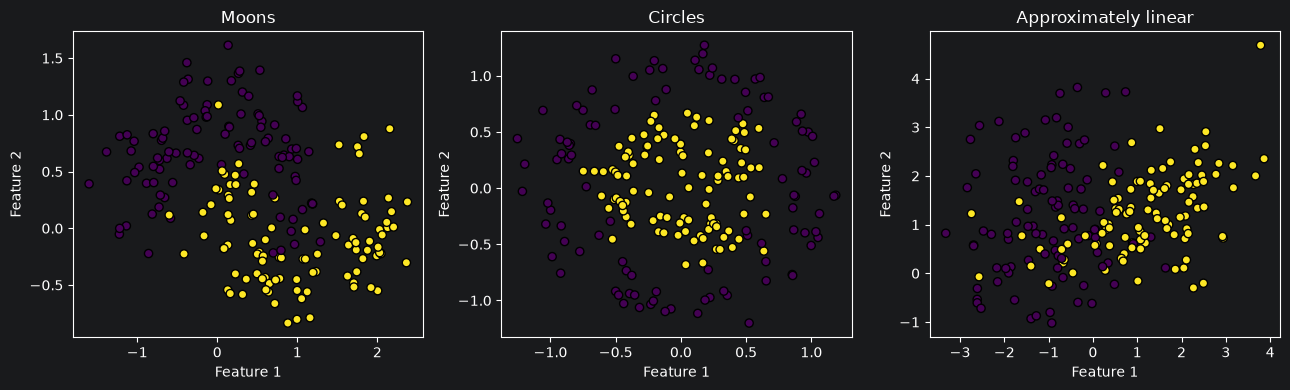

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, X, y) in zip(axes, datasets):
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black', s=35)
    ax.set_title(name)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

### Checkpoint 1

Before training any models, predict which classifier will work best on each dataset.

| Dataset              | Your predicted best classifier | Why?                                                                                                                                                                  |
|----------------------|--------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Moons                | k-NN                           | Because it makes no assumption about the shape and just looks at what is nearby, meaning we can better trace the curve of the two moons                               |
| Circles              | Gaussian Naive Bayes           | Because fits a separate variance for each class. So both will have roughly the same center but with two different spreads, giving us an inner circle and outer circle |
| Approximately linear | Linear SVM                     | Because Linear SVM searches for the best separating line and since this dataset is already roughly separated diagonally it should give us the best performance.       |

## 2. Define the classifiers

Standardization is important for distance-based methods and SVMs. We therefore place a `StandardScaler` before k-NN and the SVM.

In [4]:
classifiers = [
    (
        'Nearest Neighbors',
        make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=7)
        ),
    ),
    (
        'Linear SVM',
        make_pipeline(
            StandardScaler(),
            SVC(kernel='linear', C=1.0, probability=True, random_state=RANDOM_STATE)
        ),
    ),
    (
        'Decision Tree',
        DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    ),
    (
        'Naive Bayes',
        GaussianNB(),
    ),
]

## 3. Plot the decision boundaries

For every dataset, we split the data into 70% training and 30% testing. The number in the lower-right corner of each model panel is test accuracy.

C:\Users\ander\Github\csce5218\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\ander\Github\csce5218\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\ander\Github\csce5218\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


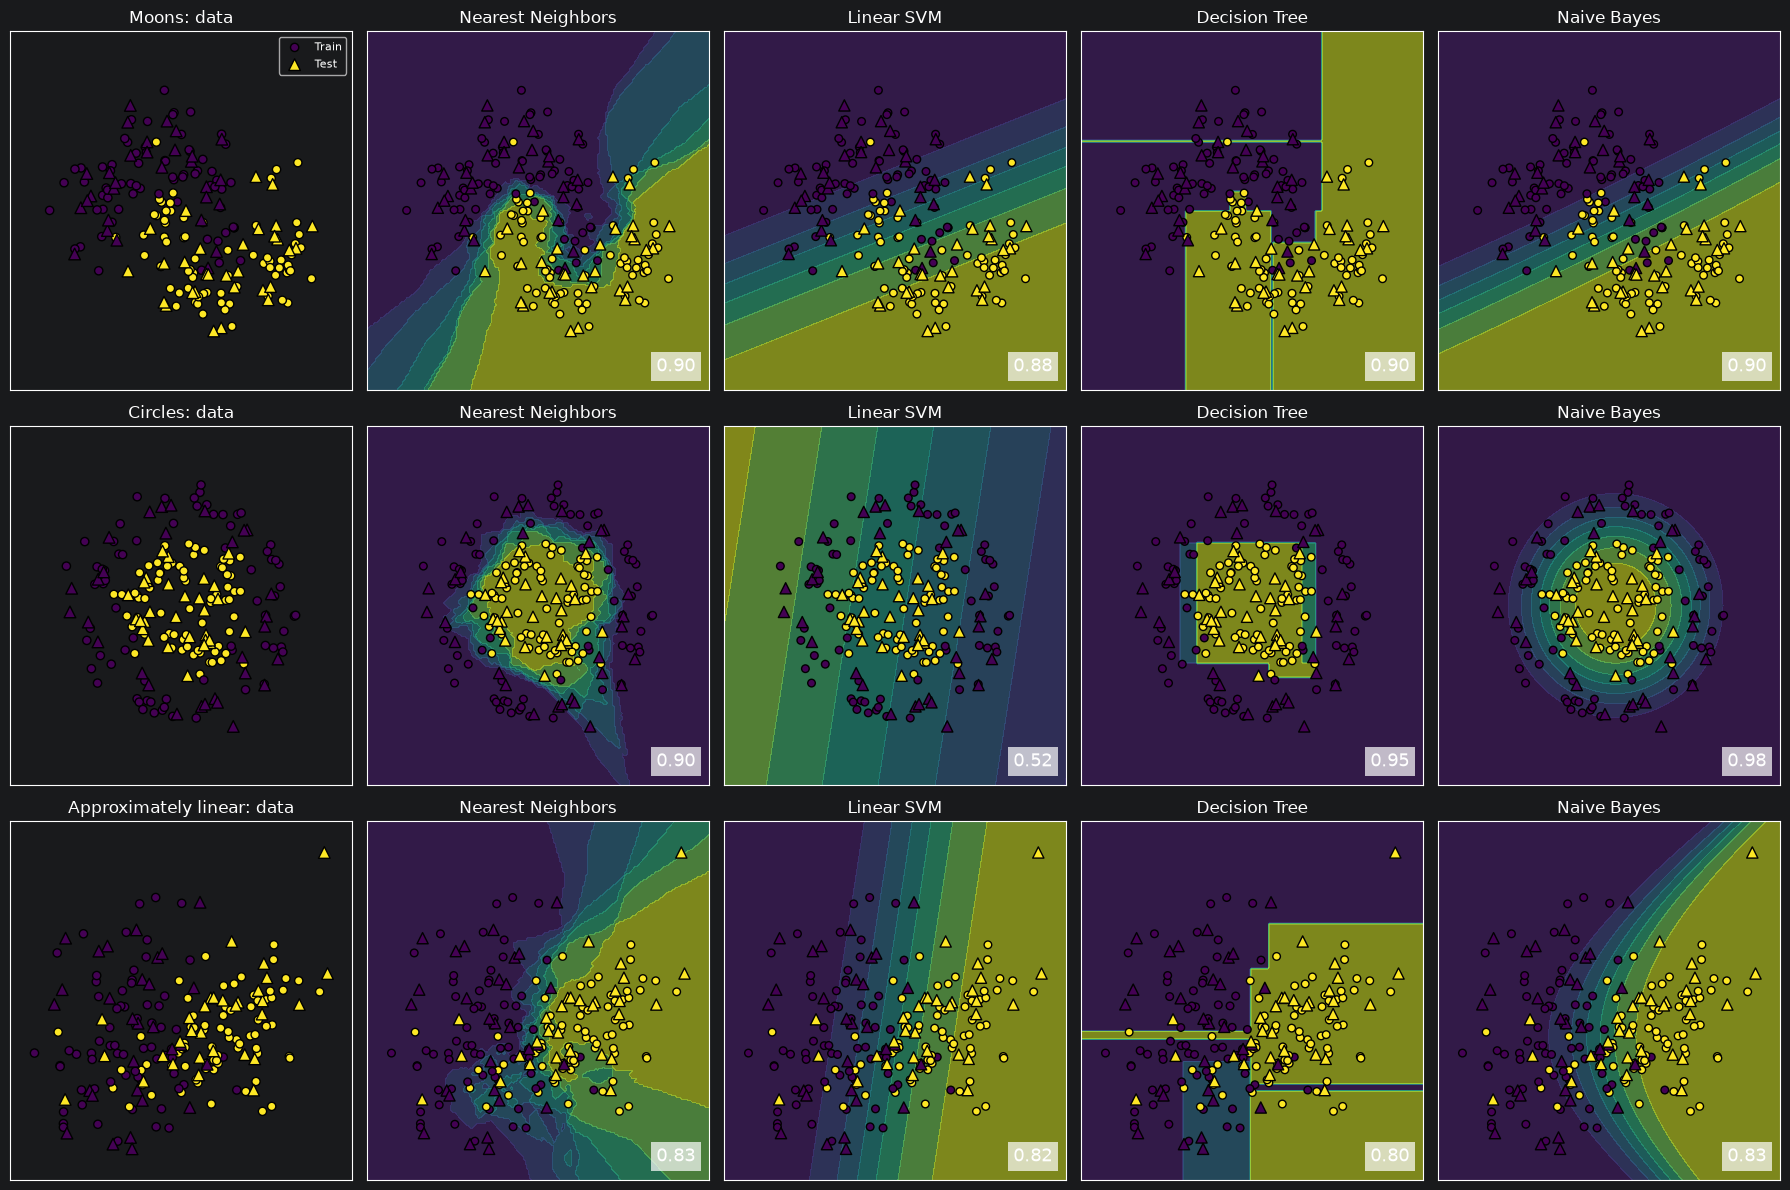

In [5]:
def plot_classifier_comparison(datasets, classifiers):
    n_rows = len(datasets)
    n_cols = len(classifiers) + 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))

    for row, (dataset_name, X, y) in enumerate(datasets):
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.30,
            stratify=y,
            random_state=RANDOM_STATE,
        )

        x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
        y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6

        # First column: raw data
        ax = axes[row, 0]
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train,
            edgecolors='black', s=35, label='Train'
        )
        ax.scatter(
            X_test[:, 0], X_test[:, 1], c=y_test,
            edgecolors='black', s=70, marker='^', label='Test'
        )
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_title(f'{dataset_name}: data')
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.legend(loc='upper right', fontsize=8)

        for col, (model_name, model) in enumerate(classifiers, start=1):
            ax = axes[row, col]
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            score = accuracy_score(y_test, y_pred)

            # probability gives a smooth confidence background
            DecisionBoundaryDisplay.from_estimator(
                model,
                X,
                response_method='predict_proba',
                class_of_interest=1,
                alpha=0.55,
                grid_resolution=250,
                ax=ax,
            )

            ax.scatter(
                X_train[:, 0], X_train[:, 1], c=y_train,
                edgecolors='black', s=30
            )
            ax.scatter(
                X_test[:, 0], X_test[:, 1], c=y_test,
                edgecolors='black', s=65, marker='^'
            )
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            ax.set_title(model_name)
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.set_xticks([])
            ax.set_yticks([])
            ax.text(
                0.96, 0.04, f'{score:.2f}',
                transform=ax.transAxes,
                ha='right', va='bottom',
                fontsize=13,
                bbox={'facecolor': 'white', 'alpha': 0.7, 'edgecolor': 'none'},
            )

    plt.tight_layout()
    plt.show()


plot_classifier_comparison(datasets, classifiers)

## 4. Interpretation guide

### k-Nearest Neighbors

- Predicts according to nearby training samples.
- Can create highly flexible, irregular boundaries.
- A small `k` may overfit; a large `k` may oversmooth.

### Linear SVM

- Produces a straight-line boundary in this two-dimensional setting.
- Works well when classes are approximately linearly separable.
- Cannot naturally represent rings or curved moon shapes with a linear kernel.

### Decision Tree

- Splits one feature at a time.
- Produces rectangular, axis-aligned decision regions.
- Deep trees can memorize training data and overfit.

### Gaussian Naive Bayes

- Models each feature as conditionally independent and Gaussian within each class.
- Often creates smooth, curved decision boundaries.
- Its assumptions can be too restrictive when features are strongly dependent.

## 5. Quantitative comparison

In [6]:
results = []

for dataset_name, X, y in datasets:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )

    for model_name, model in classifiers:
        model.fit(X_train, y_train)
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        results.append((dataset_name, model_name, train_acc, test_acc))

print(f"{'Dataset':<23} {'Classifier':<20} {'Train':>8} {'Test':>8} {'Gap':>8}")
print('-' * 72)
for dataset_name, model_name, train_acc, test_acc in results:
    print(
        f'{dataset_name:<23} {model_name:<20} '
        f'{train_acc:>8.3f} {test_acc:>8.3f} {train_acc-test_acc:>8.3f}'
    )

Dataset                 Classifier              Train     Test      Gap
------------------------------------------------------------------------
Moons                   Nearest Neighbors       0.929    0.900    0.029
Moons                   Linear SVM              0.807    0.883   -0.076
Moons                   Decision Tree           0.979    0.900    0.079
Moons                   Naive Bayes             0.807    0.900   -0.093
Circles                 Nearest Neighbors       0.921    0.900    0.021
Circles                 Linear SVM              0.550    0.517    0.033
Circles                 Decision Tree           0.957    0.950    0.007
Circles                 Naive Bayes             0.936    0.983   -0.048
Approximately linear    Nearest Neighbors       0.864    0.833    0.031
Approximately linear    Linear SVM              0.857    0.817    0.040
Approximately linear    Decision Tree           0.929    0.800    0.129
Approximately linear    Naive Bayes             0.864    0.833 

C:\Users\ander\Github\csce5218\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\ander\Github\csce5218\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\ander\Github\csce5218\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### Checkpoint 2

Answer the following:

1. Which classifier has the most irregular boundary? - k-NN is the most irregular, which is easy to see on the plots that were made. We see how the boundary is not a smooth curve but more wiggly.
2. Which classifier is most constrained by its model form? - Linear SVM is the most constrained. It is especially visible on the circle data, as it is unable to create a straight line to cleanly separate the data.
3. Which model produces axis-aligned rectangular regions? - Decision Tree, the circle is a great example as it creates this boxy circle.
4. Where do you see evidence of underfitting? - Linear SVM is underfitting on the circles data, with a train score of 0.550 and a test score of 0.517.
5. Where do you see a large train-test accuracy gap, suggesting overfitting? - Decision Tree on the approximately linear dataset, is overfitting with a gap of 0.129.

## 6. Experiment A: Change the number of neighbors

Compare `k = 1, 5, 15, 40`. Observe how the boundary becomes smoother as `k` increases.

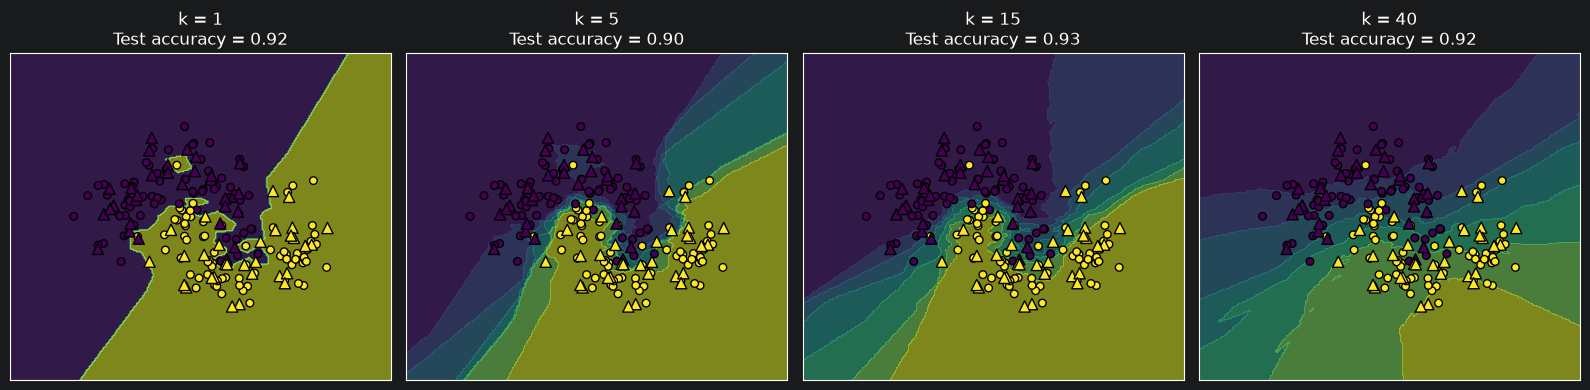

In [7]:
X, y = X_moons, y_moons
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

k_values = [1, 5, 15, 40]
fig, axes = plt.subplots(1, len(k_values), figsize=(16, 4))

for ax, k in zip(axes, k_values):
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    model.fit(X_train, y_train)

    DecisionBoundaryDisplay.from_estimator(
        model, X, response_method='predict_proba',
        class_of_interest=1, alpha=0.55,
        grid_resolution=250, ax=ax
    )
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='black', s=30)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='black', s=65, marker='^')
    ax.set_title(f'k = {k}\nTest accuracy = {model.score(X_test, y_test):.2f}')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

### Questions

1. Which value of `k` appears to overfit? - k = 1 is overfitting, which is seen with the little isolated yellow dot in the middle of all the purple.
2. Which value appears to underfit? - k = 40 is underfitting, which is seen by the more simple boundary shape.
3. Does the visually most complex boundary always have the highest test accuracy? - no, as we see k = 15, is less complex compared to k = 1, but has a better test accuracy.

## 7. Experiment B: Change tree depth

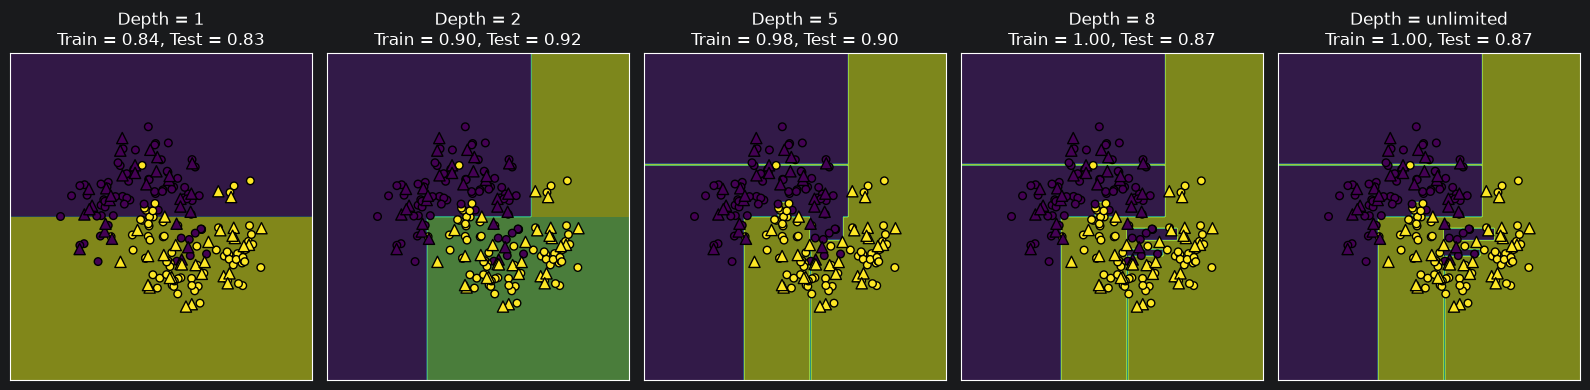

In [11]:
depths = [1, 2, 5, 8, None]
fig, axes = plt.subplots(1, len(depths), figsize=(16, 4))

for ax, depth in zip(axes, depths):
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    DecisionBoundaryDisplay.from_estimator(
        model, X, response_method='predict_proba',
        class_of_interest=1, alpha=0.55,
        grid_resolution=250, ax=ax
    )
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='black', s=30)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='black', s=65, marker='^')
    label = 'unlimited' if depth is None else str(depth)
    ax.set_title(
        f'Depth = {label}\n'
        f'Train = {model.score(X_train, y_train):.2f}, '
        f'Test = {model.score(X_test, y_test):.2f}'
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

### Questions

1. How does increasing depth affect boundary complexity? - By increasing depth you also increase the complexity of the boundary. This is seen when we compare Depth = 1 and Depth = 8.
2. At what depth does training accuracy become much higher than test accuracy? - At depth 8 we can see we get a train score of 1.00, while only getting a test score of 0.87.
3. Why are all decision-tree boundaries horizontal or vertical? - This is because decision tree boundaries are axis bound, meaning they can only go horizontal and vertical. Therefore, creating a boxy look.

## 8. Experiment C: Linear versus nonlinear SVM

The original figure uses a linear SVM. Add an RBF-kernel SVM to see how a nonlinear feature mapping changes the decision boundary.

C:\Users\ander\Github\csce5218\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\ander\Github\csce5218\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


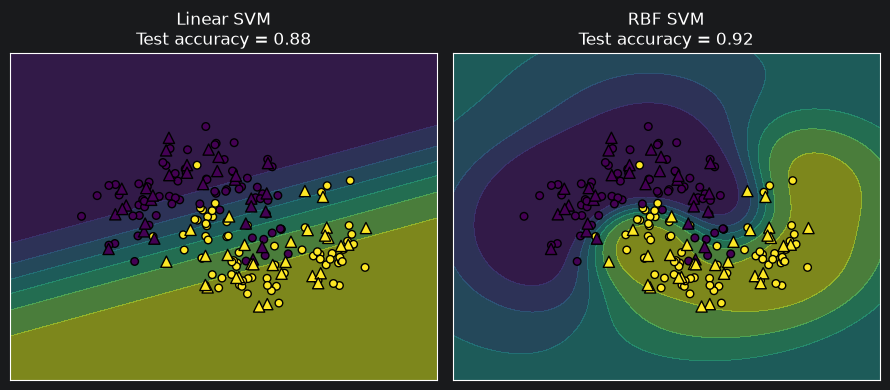

In [12]:
svm_models = [
    ('Linear SVM', make_pipeline(StandardScaler(), SVC(kernel='linear', C=1, probability=True))),
    ('RBF SVM', make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1, gamma='scale', probability=True))),
]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (name, model) in zip(axes, svm_models):
    model.fit(X_train, y_train)
    DecisionBoundaryDisplay.from_estimator(
        model, X, response_method='predict_proba',
        class_of_interest=1, alpha=0.55,
        grid_resolution=250, ax=ax
    )
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='black', s=30)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='black', s=65, marker='^')
    ax.set_title(f'{name}\nTest accuracy = {model.score(X_test, y_test):.2f}')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## 9. Optional extension: confusion matrix

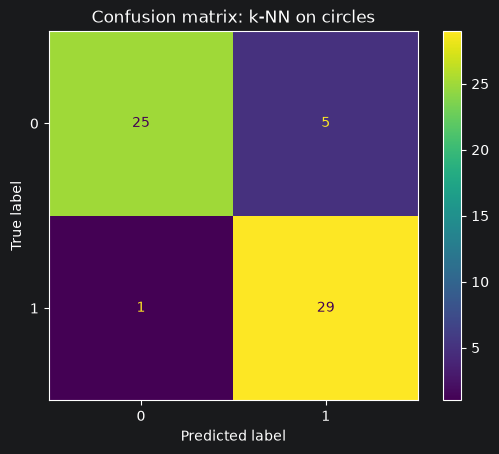

In [13]:
# Choose a dataset and classifier to inspect.
X, y = X_circles, y_circles
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=7)
)
model.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('Confusion matrix: k-NN on circles')
plt.show()

## 10. Submission questions

Submit a short response answering these questions:

1. Why does the linear SVM fail on concentric circles? - Linear SVM draws a straight line as boundary, but in the case of concentric circles we got two rings. An inner ring and an outer ring. This means there is no good way to make a straight line separating the data points. The best it can do is splitting it in half, which is seen by 0.5 scores that it gets.
2. Why does a decision tree create rectangular regions? - This is because it is axis bound, meaning it can only create boundaries that are horizontal and vertical.
3. How does increasing `k` change the bias-variance tradeoff of k-NN? - With a low k we got a low bias, but a high variances. By increasing k, we get a higher bias and lower variance. So with a lower k, it's better at finding each detail, but as we increase it gets less sensitive to noise adn creates a more smooth boundary.
4. Give one example of underfitting and one example of overfitting from your experiments. - Earlier we saw how Linear SVM is underfitting on the circles data, with a train score of 0.550 and a test score of 0.517. While the Decision Tree on the approximately linear dataset, is overfitting with a train score of 0.929 and a test score of 0.800.
5. Which classifier would you choose for each dataset, and why? - Moons: I would choose k-NN based on the test accuracy, and it's boundary flexibility. Circles: Here I would choose Gaussian Naive Bayes, as it had the highest test score, but also nearly matched the ring structure of the data perfectly. Approximately linear: Again I would choose k-NN based on its test score (tied with Naive Bayes), but also for its flexibility. It should have an easier time adapting to noise.
6. Why should model selection be based on held-out data rather than training accuracy alone? - This because the model has not seen held-out data, so we get insight into its actual performance. Compared to using training data as it has seen this data and therefore also knows it.

### Challenge

Create a fourth synthetic dataset and predict, before running the code, which classifier will perform best. Then test your prediction.

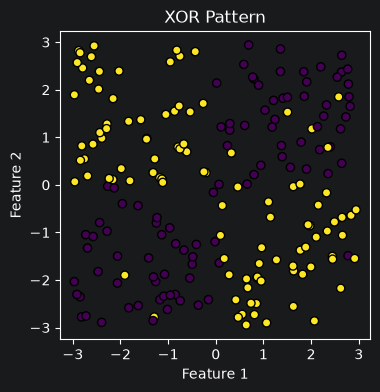

In [18]:
# Dataset 4: XOR-style pattern
rng = np.random.RandomState(RANDOM_STATE)
n_samples = 200
X_xor = rng.uniform(-3, 3, size=(n_samples, 2))
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0).astype(int)

# added noise
flip_mask = rng.rand(n_samples) < 0.05
y_xor[flip_mask] = 1 - y_xor[flip_mask]

plt.figure(figsize=(4, 4))
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, edgecolors='black', s=35)
plt.title('XOR Pattern')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Prediction
| Dataset     | Prediction    | Why?                                                                                                                                                                                   |
|-------------|---------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| XOR Pattern | Decision tree | Decision tree should have the best result based on its ability to build horizontal and vertical boundaries. I would expect it to create 4 squares, based on the data points placement. |

C:\Users\ander\Github\csce5218\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


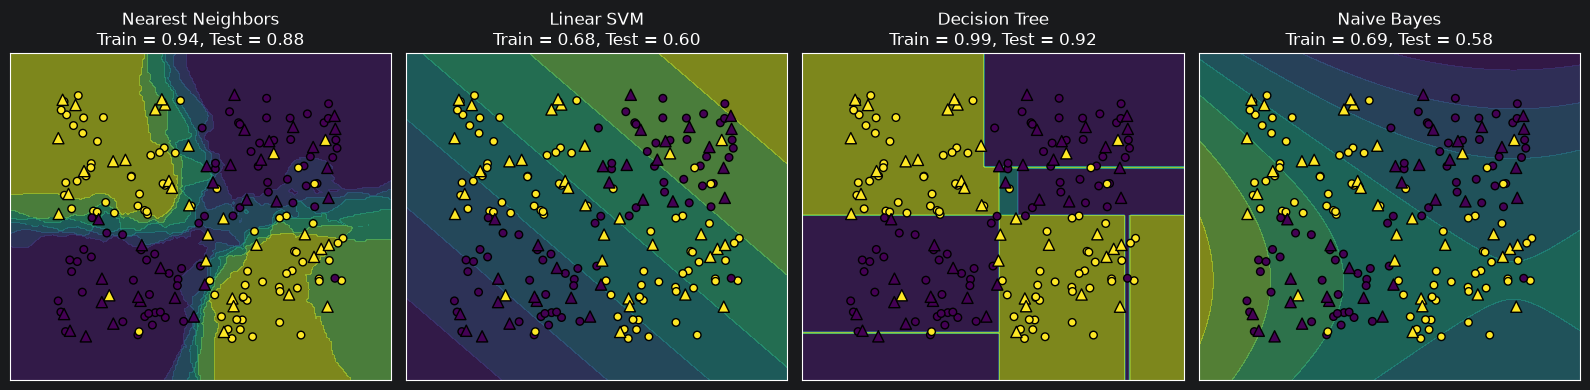

In [22]:
X, y = X_xor, y_xor
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

fig, axes = plt.subplots(1, len(classifiers), figsize=(16, 4))

for ax, (name, model) in zip(axes, classifiers):
    model.fit(X_train, y_train)

    DecisionBoundaryDisplay.from_estimator(
        model, X, response_method='predict_proba',
        class_of_interest=1, alpha=0.55,
        grid_resolution=250, ax=ax
    )
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='black', s=30)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='black', s=65, marker='^')
    ax.set_title(
        f'{name}\n'
        f'Train = {model.score(X_train, y_train):.2f}, '
        f'Test = {model.score(X_test, y_test):.2f}'
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

Here we see that my prediction was right, as it got the highest test score. It primarily creates the 4 squares, with some exceptions where it is trying to catch some of the outliers.